# Online Retail Sales Analysis
Simple analysis of a UK online retail store. We'll clean the data, find top products, check sales trends, and see which countries bring in the most money.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("online_retail.csv", encoding="latin1")
df.shape

(541909, 8)

## 1. Clean the data
Remove cancelled orders, bad rows, and add a Revenue column.

In [2]:
# cancelled orders start with 'C'
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# drop rows with no quantity, no price, or no product name
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]
df = df.dropna(subset=['Description'])

# fix types
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['Description'] = df['Description'].str.strip()
df['Country'] = df['Country'].str.strip()

# revenue per line
df['Revenue'] = df['Quantity'] * df['UnitPrice']

print("Rows after cleaning:", len(df))
df.head()

Rows after cleaning: 530104


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 2. Key numbers

In [3]:
total_revenue = df['Revenue'].sum()
total_orders = df['InvoiceNo'].nunique()
total_customers = df['CustomerID'].nunique()
avg_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.0f}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Avg Order Value: £{avg_order_value:,.2f}")

Total Revenue: £10,666,685
Total Orders: 19,960
Total Customers: 4,338
Avg Order Value: £534.40


## 3. Revenue over time
Monthly revenue to see if the business is growing or shrinking, and to spot seasonality.

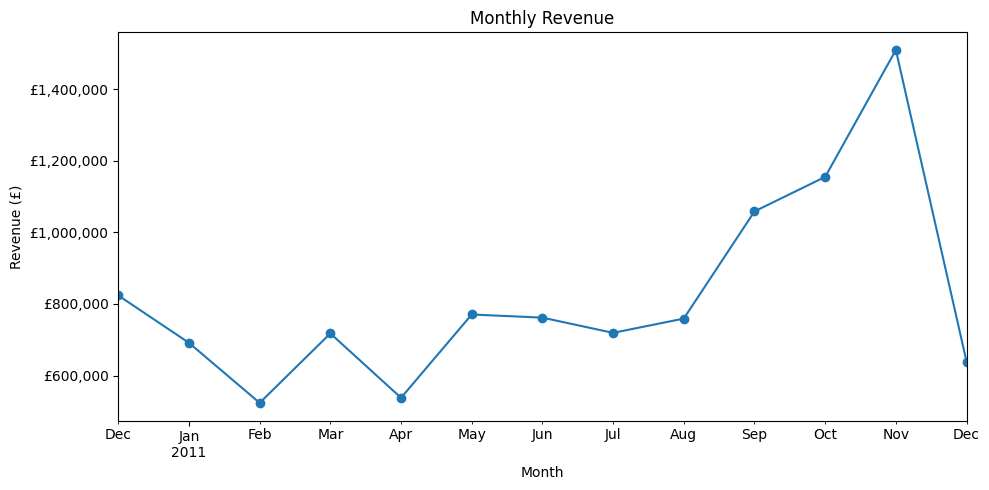

In [4]:
monthly = df.set_index('InvoiceDate').resample('ME')['Revenue'].sum()

ax = monthly.plot(marker='o')
ax.set_title("Monthly Revenue")
ax.set_ylabel("Revenue (£)")
ax.set_xlabel("Month")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'£{x:,.0f}'))
plt.tight_layout()
plt.show()

## 4. Top products
By total revenue. We drop postage, fees, and gift vouchers since those aren't real products.

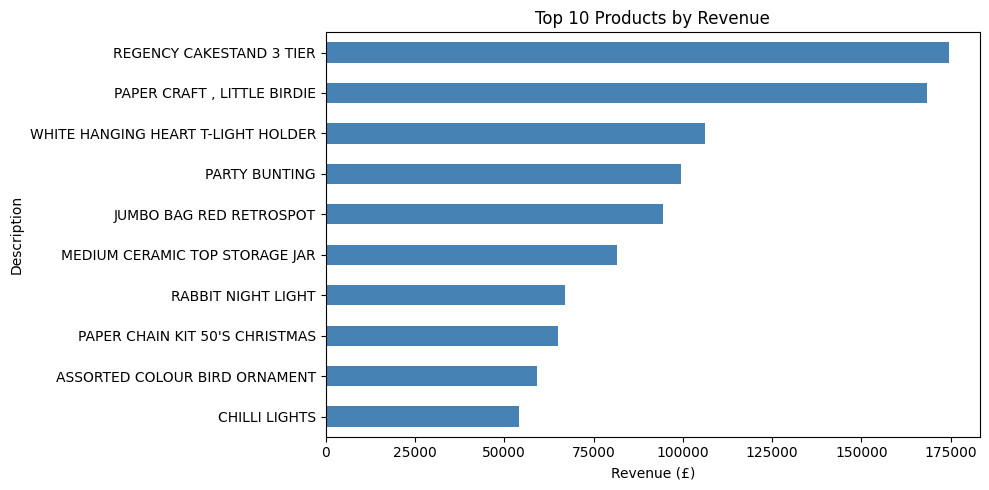

Description
REGENCY CAKESTAND 3 TIER              174484.74
PAPER CRAFT , LITTLE BIRDIE           168469.60
WHITE HANGING HEART T-LIGHT HOLDER    106292.77
PARTY BUNTING                          99504.33
JUMBO BAG RED RETROSPOT                94340.05
MEDIUM CERAMIC TOP STORAGE JAR         81700.92
RABBIT NIGHT LIGHT                     66964.99
PAPER CHAIN KIT 50'S CHRISTMAS         64952.29
ASSORTED COLOUR BIRD ORNAMENT          59094.93
CHILLI LIGHTS                          54117.76
Name: Revenue, dtype: float64

In [5]:
non_products = ['POST','DOT','M','BANK CHARGES','C2','AMAZONFEE','CRUK',
                'gift_0001_10','gift_0001_20','gift_0001_30','gift_0001_40','gift_0001_50']
products_df = df[~df['StockCode'].isin(non_products)]

top_products = products_df.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

ax = top_products.sort_values().plot(kind='barh', color='steelblue')
ax.set_title("Top 10 Products by Revenue")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

top_products

## 5. Top countries
By total revenue. UK is home market so we also check outside the UK.

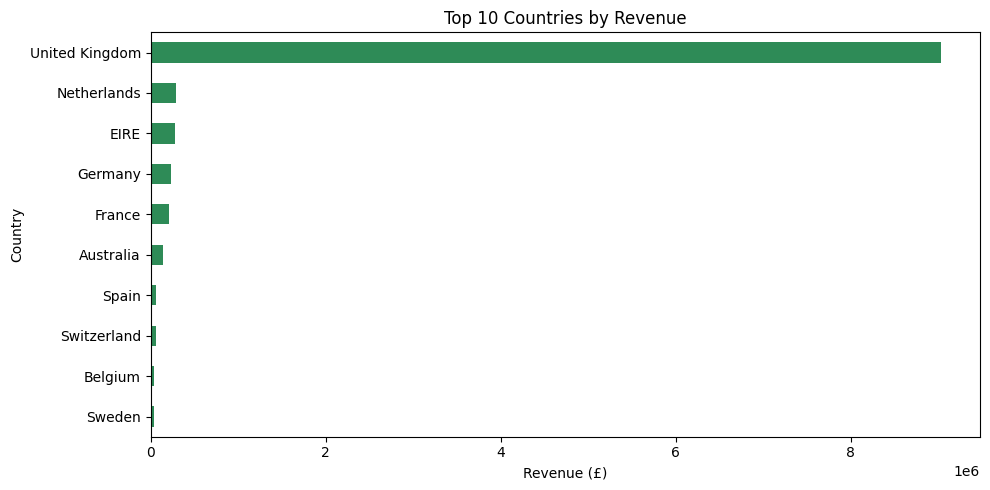

Country
United Kingdom    9025222.084
Netherlands        285446.340
EIRE               283453.960
Germany            228867.140
France             209715.110
Australia          138521.310
Spain               61577.110
Switzerland         57089.900
Belgium             41196.340
Sweden              38378.330
Name: Revenue, dtype: float64

In [6]:
top_countries = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)

ax = top_countries.sort_values().plot(kind='barh', color='seagreen')
ax.set_title("Top 10 Countries by Revenue")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

top_countries

Non-UK revenue: £1,641,462
Non-UK share of total: 15.4%


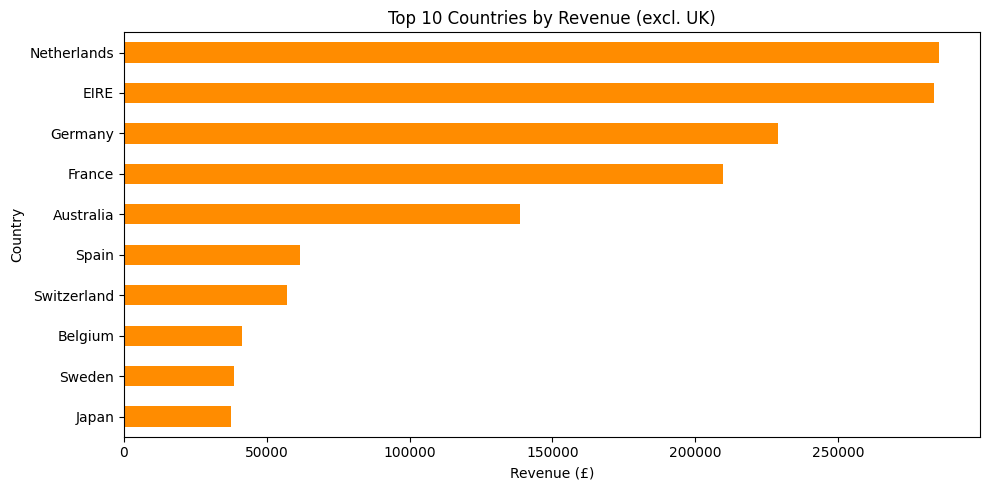

In [7]:
non_uk = df[df['Country'] != 'United Kingdom']
print(f"Non-UK revenue: £{non_uk['Revenue'].sum():,.0f}")
print(f"Non-UK share of total: {non_uk['Revenue'].sum() / total_revenue:.1%}")

top_countries_ex_uk = non_uk.groupby('Country')['Revenue'].sum().sort_values(ascending=False).head(10)
ax = top_countries_ex_uk.sort_values().plot(kind='barh', color='darkorange')
ax.set_title("Top 10 Countries by Revenue (excl. UK)")
ax.set_xlabel("Revenue (£)")
plt.tight_layout()
plt.show()

## 6. Top customers
Who are the biggest spenders. Useful for loyalty programs.

In [8]:
top_customers = df.dropna(subset=['CustomerID']).groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False).head(10)
top_customers

CustomerID
14646.0    280206.02
18102.0    259657.30
17450.0    194550.79
16446.0    168472.50
14911.0    143825.06
12415.0    124914.53
14156.0    117379.63
17511.0     91062.38
16029.0     81024.84
12346.0     77183.60
Name: Revenue, dtype: float64

## 7. Insights & recommendations

**What we found:**
- Sales grow steadily through the year and jump a lot in **Sep-Nov**, then drop off in December. This looks like holiday buying (customers order gifts early, not right before Christmas).
- A small group of products bring in a big chunk of revenue. These top products should never go out of stock.
- The **UK** is the main market by far. **Netherlands, EIRE, Germany, and France** are the strongest markets outside the UK.
- A handful of customers spend a lot more than everyone else. Losing even one of them would hurt.

**What the business should do:**
1. **Stock up early for the Sep-Nov rush** so best-sellers don't run out during peak season.
2. **Grow the top non-UK countries** (Netherlands, Germany, France) with local marketing or faster shipping, since they already buy well.
3. **Start a loyalty or rewards program** for top customers to keep them coming back.
4. **Bundle top products with slower-selling ones** to boost sales of items that don't move on their own.
5. **Watch December sales** — investigate if the drop is shipping cut-off dates, and consider earlier holiday promotions.
